vert
E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\vert\1_over_6
-1190.jpeg
-1170.jpeg
-1150.jpeg
-1130.jpeg
-1110.jpeg
-1090.jpeg
-1070.jpeg
-1050.jpeg
-1030.jpeg
-1010.jpeg
-990.jpeg
-970.jpeg
-950.jpeg
-930.jpeg
-910.jpeg


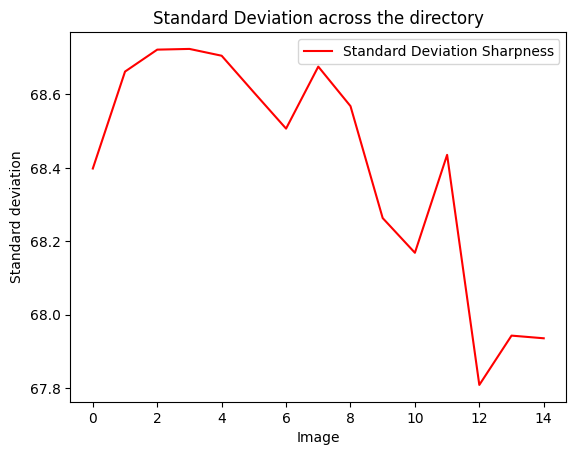

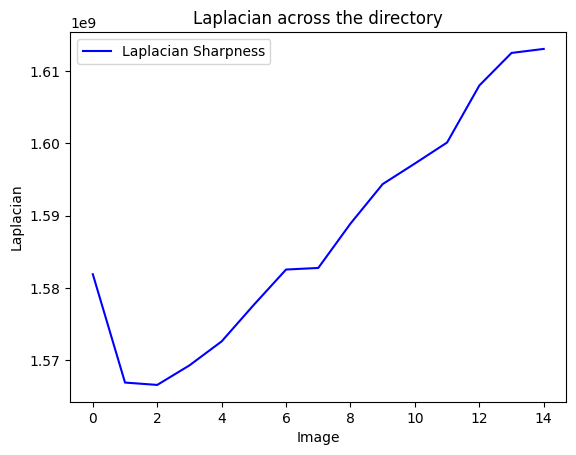

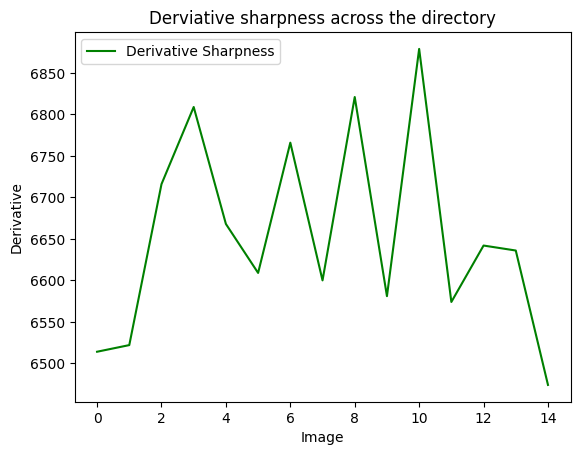

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\vert\2_over_6
-1240.jpeg
-1220.jpeg
-1200.jpeg
-1180.jpeg
-1160.jpeg
-1140.jpeg
-1120.jpeg
-1100.jpeg
-1080.jpeg
-1060.jpeg
-1040.jpeg
-1020.jpeg
-1000.jpeg
-980.jpeg
-960.jpeg


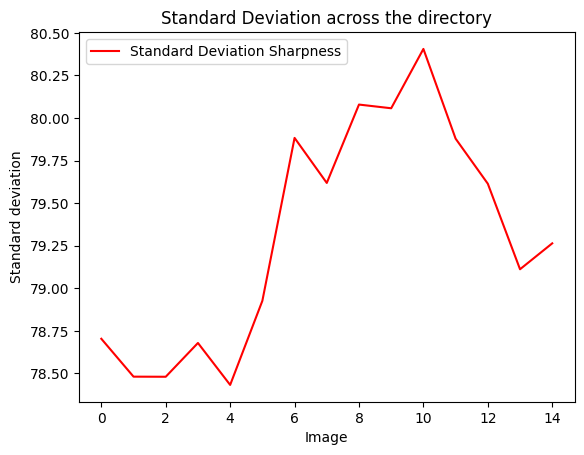

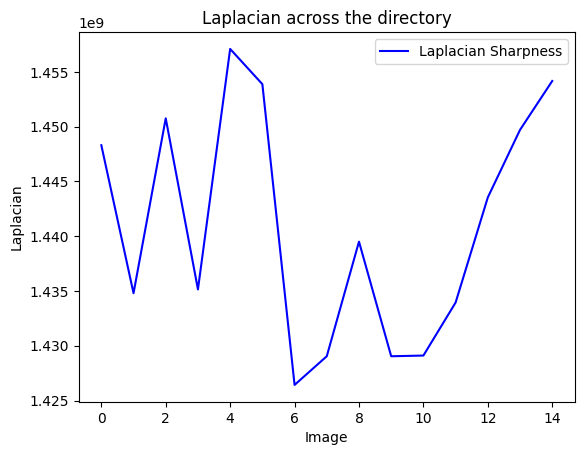

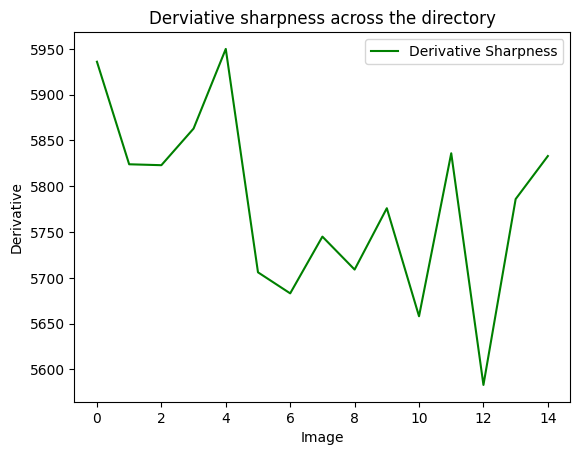

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\vert\3_over_6
-1190.jpeg
-1170.jpeg
-1150.jpeg
-1130.jpeg
-1110.jpeg
-1090.jpeg
-1070.jpeg
-1050.jpeg
-1030.jpeg
-1010.jpeg
-990.jpeg
-970.jpeg
-950.jpeg
-930.jpeg
-910.jpeg


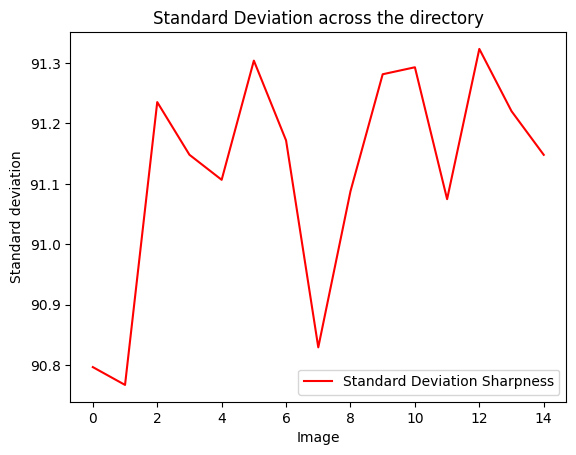

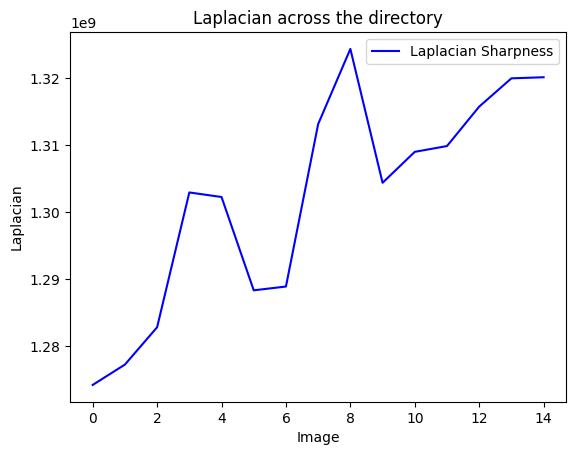

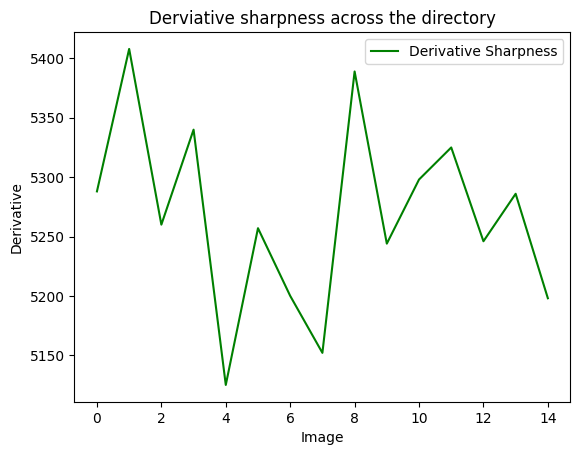

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\vert\4_over_6
-940.jpeg
-920.jpeg
-900.jpeg
-880.jpeg
-860.jpeg
-840.jpeg
-820.jpeg
-800.jpeg
-780.jpeg
-760.jpeg
-740.jpeg
-720.jpeg
-700.jpeg
-680.jpeg
-660.jpeg


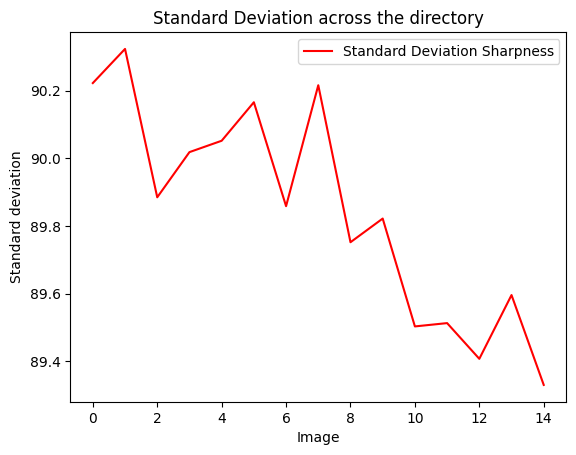

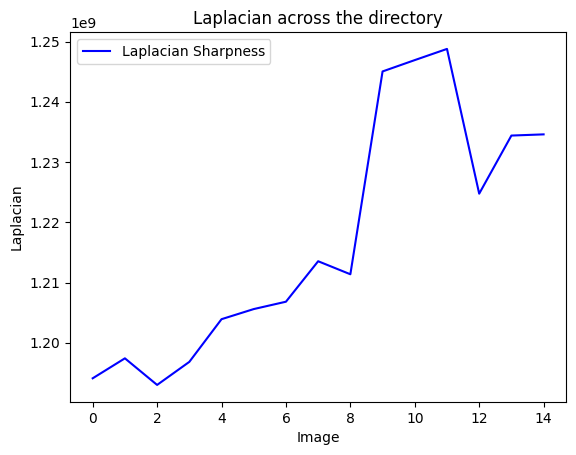

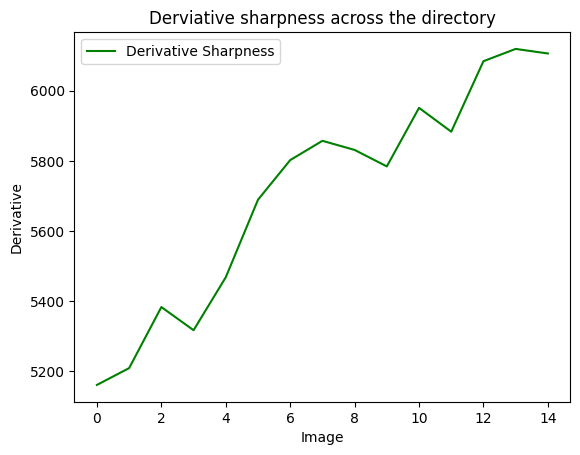

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\vert\5_over_6
-1290.jpeg
-1270.jpeg
-1250.jpeg
-1230.jpeg
-1210.jpeg
-1190.jpeg
-1170.jpeg
-1150.jpeg
-1130.jpeg
-1110.jpeg
-1090.jpeg
-1070.jpeg
-1050.jpeg
-1030.jpeg
-1010.jpeg


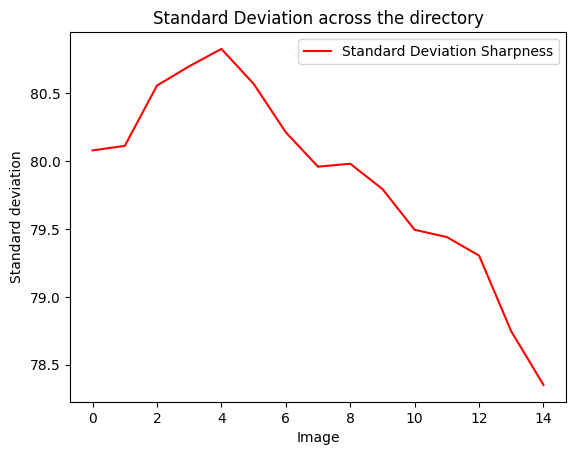

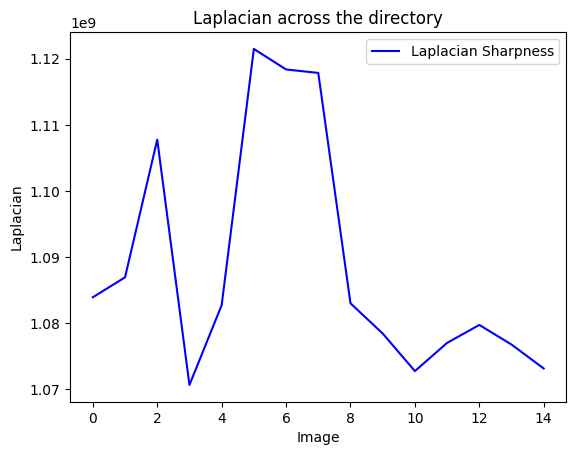

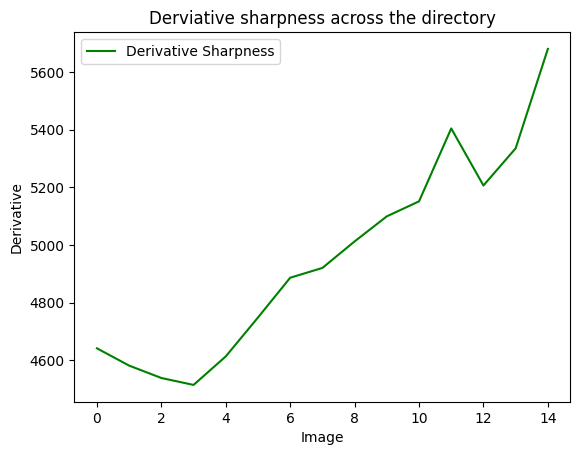

horiz
E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\horiz\1_over_6
-1340.jpeg
-1320.jpeg
-1300.jpeg
-1280.jpeg
-1260.jpeg
-1240.jpeg
-1220.jpeg
-1200.jpeg
-1180.jpeg
-1160.jpeg
-1140.jpeg
-1120.jpeg
-1100.jpeg
-1080.jpeg
-1060.jpeg


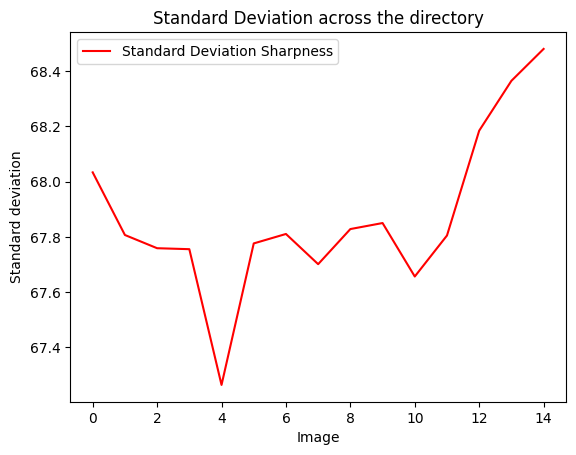

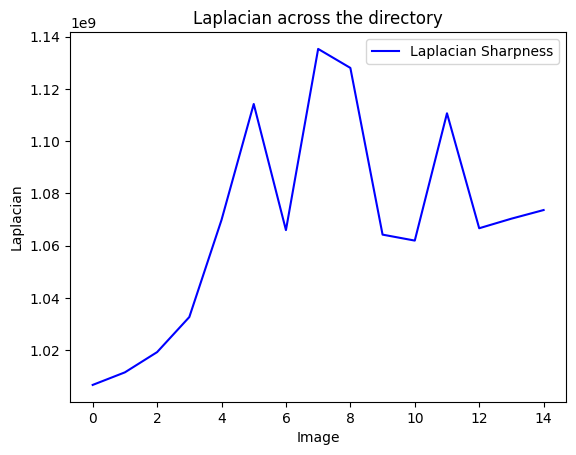

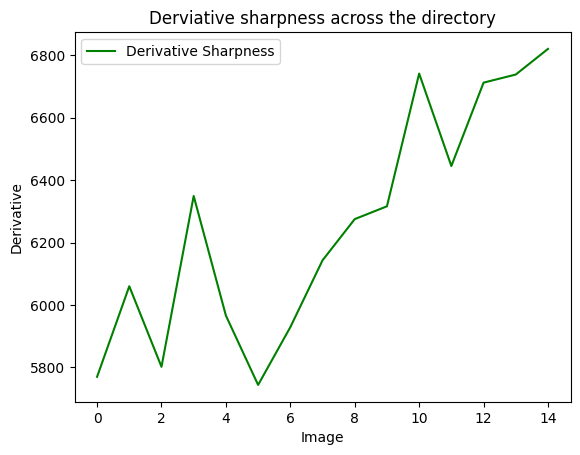

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\horiz\2_over_6
-1490.jpeg
-1470.jpeg
-1450.jpeg
-1430.jpeg
-1410.jpeg
-1390.jpeg
-1370.jpeg
-1350.jpeg
-1330.jpeg
-1310.jpeg
-1290.jpeg
-1270.jpeg
-1250.jpeg
-1230.jpeg
-1210.jpeg


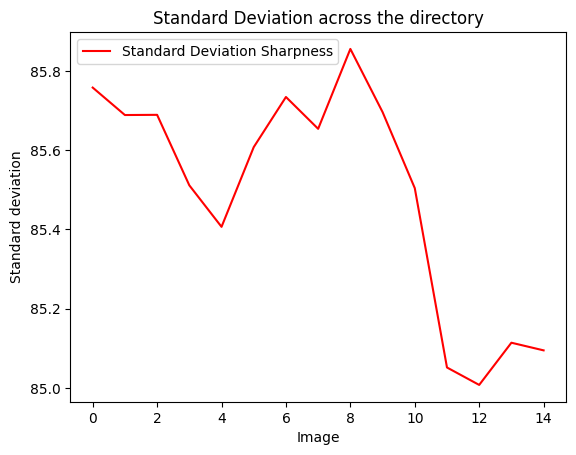

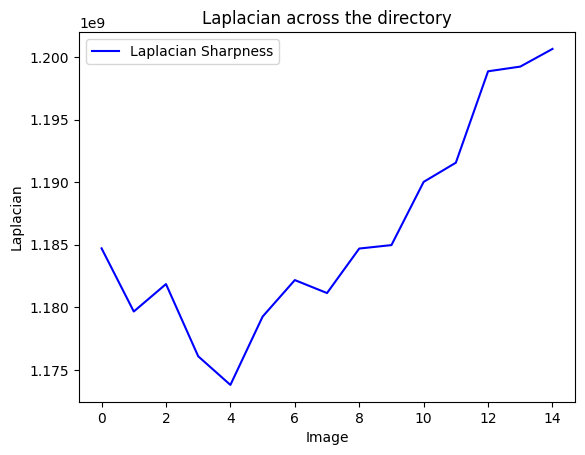

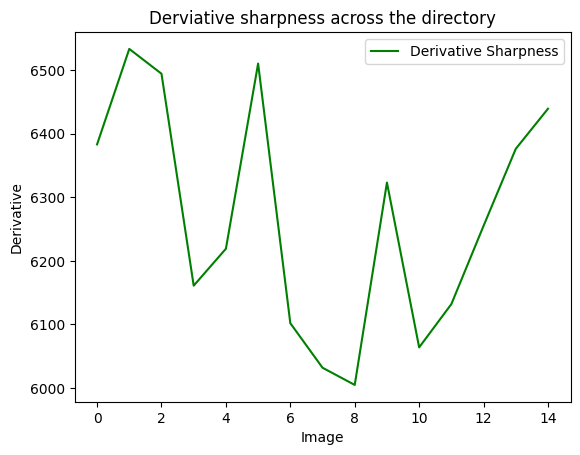

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\horiz\3_over_6
-1440.jpeg
-1420.jpeg
-1400.jpeg
-1380.jpeg
-1360.jpeg
-1340.jpeg
-1320.jpeg
-1300.jpeg
-1280.jpeg
-1260.jpeg
-1240.jpeg
-1220.jpeg
-1200.jpeg
-1180.jpeg
-1160.jpeg


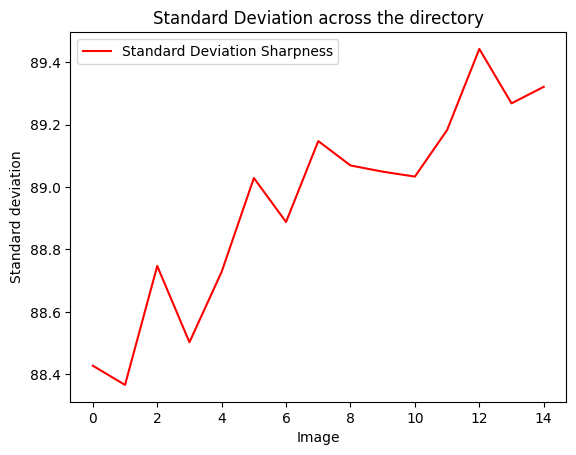

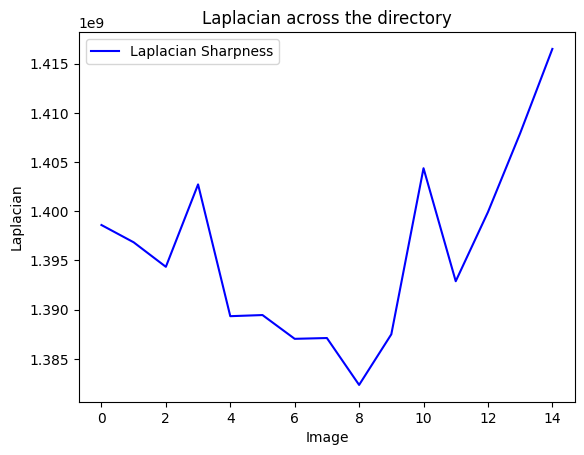

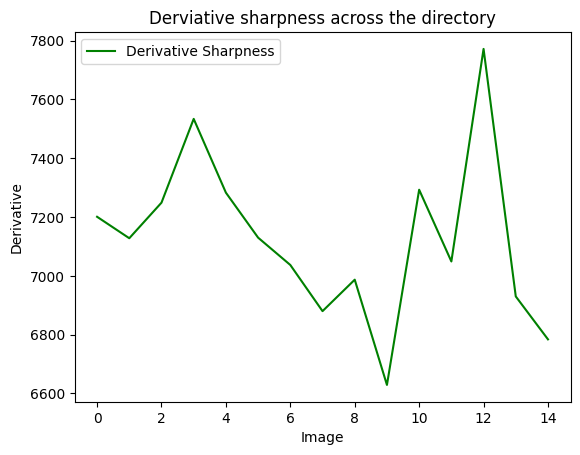

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\horiz\4_over_6
-1290.jpeg
-1270.jpeg
-1250.jpeg
-1230.jpeg
-1210.jpeg
-1190.jpeg
-1170.jpeg
-1150.jpeg
-1130.jpeg
-1110.jpeg
-1090.jpeg
-1070.jpeg
-1050.jpeg
-1030.jpeg
-1010.jpeg


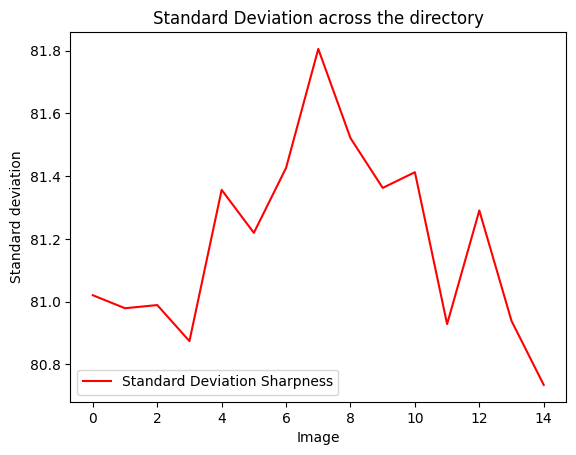

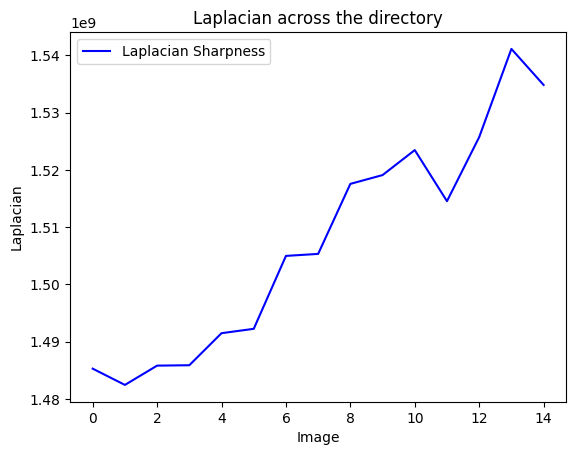

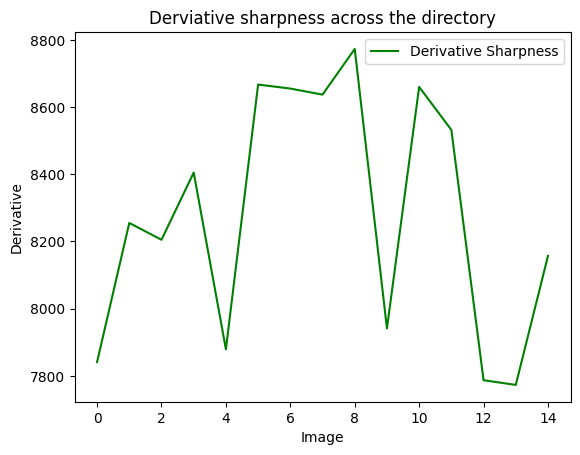

E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x\horiz\5_over_6
-1340.jpeg


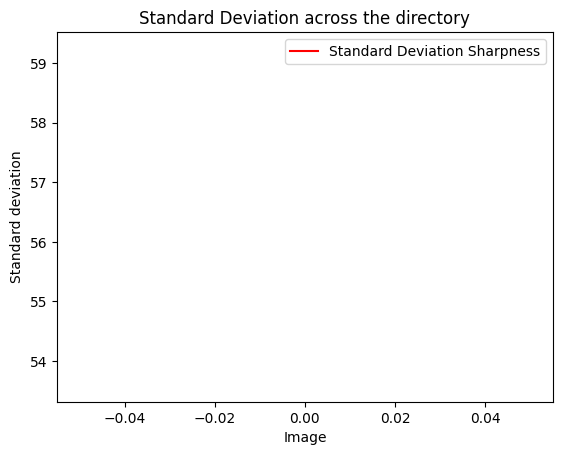

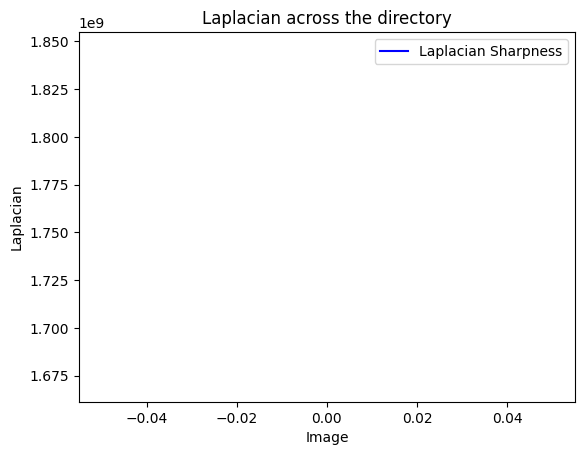

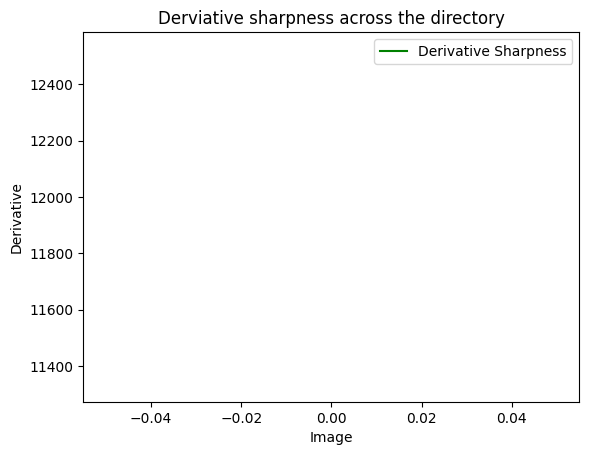

In [12]:

import matplotlib.pyplot as plt
import os
import cv2
import usafocus
import numpy as np
from PIL import Image

def extract_number(filename):
    # Extract the numeric part from the filename
    return int(''.join(filter(str.isdigit, filename)))


dirtop = r"E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_13_2024-16_56_28_40x"

for i in ["vert","horiz"]:
    print(i)
    directory = os.path.join(dirtop, i)
    paths =  [os.path.join(directory, d) for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]


    for path in paths:
        print(path)
        jpeg_files = [f for f in os.listdir(path) if f.endswith('.jpeg') and os.path.isfile(os.path.join(path, f))]
        jpeg_files.sort(key=extract_number, reverse=True)
        std_devs = []
        laplacian = []
        derives = []


        for image in jpeg_files:
            print(image)
            img = Image.open(os.path.join(path, image))
            numpydata = np.asarray(img)

            std_devs.append(usafocus.standard_deviation(numpydata))
            laplacian.append(usafocus.edge_laplacian(numpydata))
            derives.append(usafocus.measure_derivs(numpydata))



        plt.plot(std_devs, label='Standard Deviation Sharpness', color = 'red')
            
        plt.xlabel('Image')
        plt.ylabel('Standard deviation')
        plt.title("Standard Deviation across the directory")
        plt.legend()
        plt.show()
        plt.close()
        plt.plot(laplacian, label='Laplacian Sharpness', color = 'blue')
            
        plt.xlabel('Image')
        plt.ylabel('Laplacian')
        plt.title("Laplacian across the directory")
        plt.legend()
        plt.show()
        plt.close()

        plt.plot(derives, label='Derivative Sharpness', color = 'green')
            
        plt.xlabel('Image')
        plt.ylabel('Derivative')
        plt.title("Derviative sharpness across the directory")
        plt.legend()
        plt.show()
        plt.close()